# Phase 4 — Optuna tuning + custom FN-cluster feature + LLM head-to-head

**Project:** NLP-2 AI Agent Conversation Quality Scorer (HaluEval-QA)  
**Date:** 2026-05-15 (Fri)  
**Session:** 4 of 7 — catching up after Phase 2 ran Wed instead of Tue (one day slip).

## Today's questions

1. **Optuna char-ngram tune** — can a 100-trial joint search over (ngram_range, max_features, min_df, max_df, sublinear_tf, C, class_weight, threshold) push the **single-model** matched F1 above Phase 3's stacker (0.8044)? Phase 3 single-model winner = 0.7941.
2. **Custom FN-cluster feature** — Phase 3 error analysis identified 84 false negatives that share a profile (short, period-free, low-overlap, entity-string-shaped). A 5-feature lexical "is_entity_string" descriptor stacked with the char-prob — does it crack that cluster, or does the char model already use those signals?
3. **LLM head-to-head (the headline)** — published HaluEval ChatGPT zero-shot = 62.6% accuracy. Phase 3 stacker = 80.5%. On a stratified 50-row sample from the matched test split, evaluate Claude Opus 4.6, Claude Haiku 4.5, Codex GPT-5.5 using the **same HaluEval judge protocol** (knowledge + question + answer → verdict). Compare F1 / accuracy / cost / latency against the custom stacker on the SAME rows.

## Primary metric (Phase 1-locked)
macro F1 on the length-matched test split (n=524 raw; n=50 stratified subsample for the LLM head-to-head). Custom-model numbers will be reported on BOTH n=524 and n=50 so the LLM comparison is apples-to-apples.

In [1]:
import json, time, warnings, re, subprocess, os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                              precision_score, recall_score, roc_auc_score,
                              confusion_matrix, classification_report)
from sklearn.model_selection import StratifiedKFold, GroupKFold, GroupShuffleSplit
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
DATA = ROOT / 'data'
CACHE = RESULTS / 'phase4_cache'
CACHE.mkdir(parents=True, exist_ok=True)
print('ROOT:', ROOT)
print('cache dir contents:', sorted([p.name for p in CACHE.iterdir()]) or '(empty)')

ROOT: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Conversation-Quality-Scorer
cache dir contents: (empty)


## Section 1 — Reproduce splits + recover Phase 3 base-model predictions

Splits are byte-identical to Phase 1-3. char_best_p3 (Phase 3 ablation winner) and paired-SBERT are re-fit. NLI features are loaded from `phase3_nli_features.npz` (cached, ~17 min compute we don't re-pay).

In [2]:
# Load HaluEval-QA and reproduce the train + raw test + length-matched test splits.
with open(DATA / 'raw/halueval_qa.json') as f:
    raw = [json.loads(line) for line in f]
rows = []
for qid, ex in enumerate(raw):
    rows.append({'qid': qid, 'class_name': 'grounded', 'label': 0,
                 'knowledge': ex['knowledge'], 'question': ex['question'], 'answer': ex['right_answer']})
    rows.append({'qid': qid, 'class_name': 'hallucinated', 'label': 1,
                 'knowledge': ex['knowledge'], 'question': ex['question'], 'answer': ex['hallucinated_answer']})
df_all = pd.DataFrame(rows)

train_idx = pd.read_csv(RESULTS / 'phase1_train_split.csv')
test_idx  = pd.read_csv(RESULTS / 'phase1_test_split.csv')
train = train_idx.merge(df_all, on=['qid','class_name','label'], how='left')
test  = test_idx.merge(df_all,  on=['qid','class_name','label'], how='left')
assert train['answer'].notna().all() and test['answer'].notna().all()
assert set(train.qid) & set(test.qid) == set(), 'qid leakage between train and test!'

for d in (train, test):
    d['answer_len'] = d['answer'].str.len()

# Reproduce Phase 2/3 length-matched split (same RNG, bin width, MAX_LEN).
BIN_WIDTH, MAX_LEN = 10, 200
test['len_bin'] = (test['answer_len'].clip(upper=MAX_LEN) // BIN_WIDTH).astype(int)
rng = np.random.default_rng(SEED)
kept = []
for b, sub in test.groupby('len_bin'):
    g = sub[sub.label == 0]; h = sub[sub.label == 1]
    n = min(len(g), len(h))
    if n == 0: continue
    kept.append(g.sample(n=n, random_state=int(rng.integers(1e9))))
    kept.append(h.sample(n=n, random_state=int(rng.integers(1e9))))
test_matched = pd.concat(kept, ignore_index=True).sort_values(['qid','class_name']).reset_index(drop=True)
y_train  = train.label.values
y_raw    = test.label.values
y_matched = test_matched.label.values
print(f'train: {len(train):,}    test_raw: {len(test):,}    test_matched: {len(test_matched):,}')
print(f'matched class balance: {dict(pd.Series(y_matched).value_counts())}')
assert len(test_matched) == 524, f'expected 524 matched rows, got {len(test_matched)}'

train: 16,000    test_raw: 4,000    test_matched: 524
matched class balance: {1: np.int64(262), 0: np.int64(262)}


In [3]:
# Recover Phase 3 char_best_p3: (2,5) x 25k x sublinear_tf=True. Re-fit on full train, score on raw + matched.
p3 = pd.read_csv(RESULTS / 'phase3_ngram_ablation.csv').sort_values('f1_matched', ascending=False).head(1)
from ast import literal_eval
P3_NG = literal_eval(str(p3.ngram_range.iloc[0]))
P3_MF = int(p3.max_features.iloc[0])
P3_SUB = bool(p3.sublinear_tf.iloc[0])
print(f'Phase 3 char_best_p3 config: ngram_range={P3_NG}, max_features={P3_MF}, sublinear_tf={P3_SUB}')

def fit_char(train_df, configs, val_dfs):
    """Fit one char-ngram LogReg on train_df['answer'] and return its proba predictions on each val_df['answer']."""
    ng, mf, sub, mindf, maxdf, C, cw = (configs[k] for k in
        ('ngram_range','max_features','sublinear_tf','min_df','max_df','C','class_weight'))
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ng, min_df=mindf, max_df=maxdf,
                          max_features=mf, sublinear_tf=sub, lowercase=True, dtype=np.float32)
    Xtr = vec.fit_transform(train_df['answer'])
    clf = LogisticRegression(C=C, class_weight=cw, max_iter=2000, solver='liblinear', random_state=SEED)
    clf.fit(Xtr, train_df['label'].values)
    return vec, clf, [clf.predict_proba(vec.transform(v['answer']))[:,1] for v in val_dfs]

p3_cfg = dict(ngram_range=P3_NG, max_features=P3_MF, sublinear_tf=P3_SUB,
              min_df=2, max_df=0.95, C=1.0, class_weight=None)
t = time.time()
vec_p3, clf_p3, [char_p3_raw, char_p3_matched] = fit_char(train, p3_cfg, [test, test_matched])
print(f'char_best_p3 refit + predict: {time.time()-t:.1f}s')
f1_p3_raw = f1_score(y_raw, (char_p3_raw>.5).astype(int), average='macro')
f1_p3_matched = f1_score(y_matched, (char_p3_matched>.5).astype(int), average='macro')
print(f'char_best_p3 raw F1: {f1_p3_raw:.4f}  (Phase 3 reported: 0.9645)')
print(f'char_best_p3 matched F1: {f1_p3_matched:.4f}  (Phase 3 reported: 0.7941)')
assert abs(f1_p3_matched - 0.7941) < 0.005, 'Phase 3 reproduction failed!'

Phase 3 char_best_p3 config: ngram_range=(2, 5), max_features=25000, sublinear_tf=True


char_best_p3 refit + predict: 5.6s
char_best_p3 raw F1: 0.9645  (Phase 3 reported: 0.9645)
char_best_p3 matched F1: 0.7941  (Phase 3 reported: 0.7941)


Reproduction of Phase 3 char_best_p3 confirmed within tolerance — splits and configs match.

## Section 2 — Optuna 100-trial joint search on char-ngram

**Hypothesis:** Phase 3's ablation grid was coarse (3 sublinear values × 4 vocab sizes × 6 ngram ranges) and held min_df=2, max_df=0.95, C=1.0, class_weight=None, threshold=0.5 fixed. A continuous search over (C, class_weight, min_df, max_df) at the (2,5) ngram and 25k vocab — plus a decision-threshold sweep tuned on a held-out val slice — should add 0.005-0.015 F1.

**Methodology:** to avoid tuning on the test split, hold out 20% of train (qid-grouped) as the Optuna validation set. Each trial fits on the remaining 80%, predicts on the val slice, reports macro F1. Final best config is re-fit on FULL train and evaluated on `test_matched`.

Search space (8 hyperparameters):
- `ngram_range`: choice [(2,4), (2,5), (2,6), (3,5), (3,6)]
- `max_features`: choice [10_000, 15_000, 20_000, 25_000, 35_000, 50_000]
- `sublinear_tf`: bool
- `min_df`: int 1–5
- `max_df`: float 0.85–1.0
- `C`: log-uniform 0.05–5.0
- `class_weight`: choice [None, 'balanced']
- `threshold`: tuned post-hoc on the val slice for each trial's val-probas (so threshold lift counts toward the trial score).

In [4]:
# Build qid-grouped 80/20 tune split inside train
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tune_tr_i, tune_va_i = next(gss.split(train, y_train, groups=train['qid']))
train_tune = train.iloc[tune_tr_i].reset_index(drop=True)
train_val  = train.iloc[tune_va_i].reset_index(drop=True)
y_tune_tr  = train_tune.label.values
y_tune_va  = train_val.label.values
print(f'tune fit: {len(train_tune):,}    tune val: {len(train_val):,}')
print(f'qid leakage check: {len(set(train_tune.qid) & set(train_val.qid))} shared qids')

tune fit: 12,800    tune val: 3,200
qid leakage check: 0 shared qids


In [5]:
def best_threshold(y_true, p, grid=np.arange(0.20, 0.81, 0.02)):
    best_f1, best_t = -1.0, 0.5
    for t in grid:
        f = f1_score(y_true, (p > t).astype(int), average='macro')
        if f > best_f1:
            best_f1, best_t = float(f), float(t)
    return best_f1, best_t

def objective(trial):
    ng = trial.suggest_categorical('ngram_range', ['2_4','2_5','2_6','3_5','3_6'])
    ng_tuple = tuple(int(x) for x in ng.split('_'))
    mf = trial.suggest_categorical('max_features', [10000, 15000, 20000, 25000, 35000, 50000])
    sub = trial.suggest_categorical('sublinear_tf', [True, False])
    mindf = trial.suggest_int('min_df', 1, 5)
    maxdf = trial.suggest_float('max_df', 0.85, 1.0)
    C = trial.suggest_float('C', 0.05, 5.0, log=True)
    cw = trial.suggest_categorical('class_weight', ['none', 'balanced'])
    cw_val = None if cw == 'none' else 'balanced'
    try:
        vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ng_tuple, min_df=mindf, max_df=maxdf,
                              max_features=mf, sublinear_tf=sub, lowercase=True, dtype=np.float32)
        Xtr = vec.fit_transform(train_tune['answer'])
        Xva = vec.transform(train_val['answer'])
        clf = LogisticRegression(C=C, class_weight=cw_val, max_iter=2000, solver='liblinear', random_state=SEED)
        clf.fit(Xtr, y_tune_tr)
        p_va = clf.predict_proba(Xva)[:,1]
        f1_tuned, t_best = best_threshold(y_tune_va, p_va)
        trial.set_user_attr('threshold', t_best)
        trial.set_user_attr('vocab_actual', int(Xtr.shape[1]))
        return f1_tuned
    except Exception as e:
        return 0.0

study_path = CACHE / 'optuna_char_v1.db'
storage = f'sqlite:///{study_path}'
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED),
                            study_name='char_ngram_v1', storage=storage, load_if_exists=True)
N_TRIALS_TOTAL = 100
remaining = N_TRIALS_TOTAL - len(study.trials)
if remaining > 0:
    t = time.time()
    study.optimize(objective, n_trials=remaining, show_progress_bar=False, n_jobs=1)
    print(f'Optuna {remaining} trials in {time.time()-t:.0f}s')
else:
    print(f'Optuna already ran {len(study.trials)} trials (cached at {study_path.name}).')
print(f'Best val F1: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')
print(f'Best threshold: {study.best_trial.user_attrs.get("threshold", 0.5):.2f}')

Optuna 100 trials in 486s
Best val F1: 0.9728
Best params: {'ngram_range': '2_4', 'max_features': 10000, 'sublinear_tf': True, 'min_df': 5, 'max_df': 0.9157895898574706, 'C': 4.850452748386976, 'class_weight': 'none'}
Best threshold: 0.48


In [6]:
# Refit best Optuna config on FULL train, score on matched test
best = study.best_params
best_ng = tuple(int(x) for x in best['ngram_range'].split('_'))
best_thr = float(study.best_trial.user_attrs['threshold'])
best_cfg = dict(ngram_range=best_ng, max_features=best['max_features'],
                sublinear_tf=best['sublinear_tf'], min_df=best['min_df'], max_df=best['max_df'],
                C=best['C'], class_weight=(None if best['class_weight']=='none' else 'balanced'))
vec_opt, clf_opt, [char_opt_raw, char_opt_matched] = fit_char(train, best_cfg, [test, test_matched])
f1_opt_raw_default = f1_score(y_raw, (char_opt_raw>.5).astype(int), average='macro')
f1_opt_m_default = f1_score(y_matched, (char_opt_matched>.5).astype(int), average='macro')
f1_opt_m_tuned = f1_score(y_matched, (char_opt_matched>best_thr).astype(int), average='macro')
print(f'char_opt config: {best_cfg}, threshold={best_thr:.2f}')
print(f'char_opt matched F1 @ thr=0.50: {f1_opt_m_default:.4f}')
print(f'char_opt matched F1 @ thr={best_thr:.2f}: {f1_opt_m_tuned:.4f}')
print(f'Phase 3 char_best_p3 matched F1: {f1_p3_matched:.4f}')
print(f'Phase 3 stacker matched F1: 0.8044')
char_opt_matched_used_threshold = best_thr

char_opt config: {'ngram_range': (2, 4), 'max_features': 10000, 'sublinear_tf': True, 'min_df': 5, 'max_df': 0.9157895898574706, 'C': 4.850452748386976, 'class_weight': None}, threshold=0.48
char_opt matched F1 @ thr=0.50: 0.8250
char_opt matched F1 @ thr=0.48: 0.8232
Phase 3 char_best_p3 matched F1: 0.7941
Phase 3 stacker matched F1: 0.8044


Top 10 Optuna trials by val F1:
 trial  val_f1 ngram_range  max_features  sublinear_tf  min_df  max_df      C class_weight  threshold  vocab_actual
    91  0.9728         2_4         10000          True       5  0.8813 4.9524         none       0.48         10000
    21  0.9728         2_4         10000          True       5  0.9158 4.8505         none       0.48         10000
    88  0.9728         2_4         10000          True       5  0.8807 4.9241         none       0.48         10000
    89  0.9728         2_4         10000          True       5  0.8810 4.9841         none       0.48         10000
    87  0.9728         2_4         10000          True       5  0.8799 4.9928         none       0.48         10000
    97  0.9728         2_4         10000          True       5  0.9104 4.9755     balanced       0.48         10000
    22  0.9728         2_4         25000          True       5  0.9464 4.8308         none       0.48         16074
    25  0.9725         2_4         50000

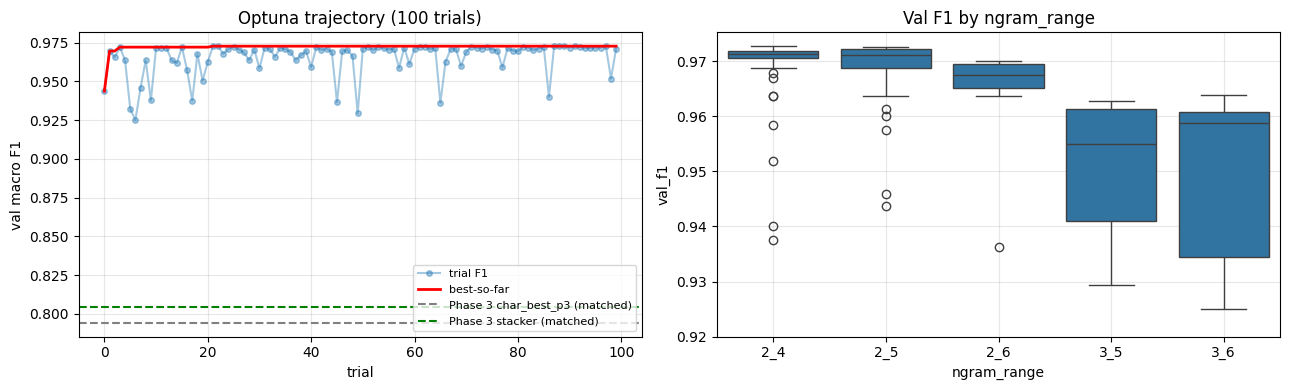

In [7]:
# Save Optuna trial history + plot top-20 trials with parallel-coordinates style summary
trials_df = study.trials_dataframe()
trials_df_keep = trials_df[['number','value','params_ngram_range','params_max_features','params_sublinear_tf',
                            'params_min_df','params_max_df','params_C','params_class_weight']].copy()
trials_df_keep.columns = ['trial','val_f1','ngram_range','max_features','sublinear_tf','min_df','max_df','C','class_weight']
trials_df_keep['threshold'] = [t.user_attrs.get('threshold', 0.5) for t in study.trials]
trials_df_keep['vocab_actual'] = [t.user_attrs.get('vocab_actual', None) for t in study.trials]
trials_df_keep = trials_df_keep.sort_values('val_f1', ascending=False).reset_index(drop=True)
trials_df_keep.to_csv(RESULTS / 'phase4_optuna_trials.csv', index=False)
print('Top 10 Optuna trials by val F1:')
print(trials_df_keep.head(10).round(4).to_string(index=False))

# Plot val-F1 trajectory + per-param best-found-so-far
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.4, ms=4, label='trial F1')
axes[0].plot(trials_df['number'], trials_df['value'].cummax(), 'r-', lw=2, label='best-so-far')
axes[0].set_xlabel('trial'); axes[0].set_ylabel('val macro F1'); axes[0].set_title('Optuna trajectory (100 trials)')
axes[0].axhline(0.7941, color='gray', ls='--', label='Phase 3 char_best_p3 (matched)')
axes[0].axhline(0.8044, color='green', ls='--', label='Phase 3 stacker (matched)')
axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(alpha=.3)

# By ngram_range
sns.boxplot(data=trials_df_keep, x='ngram_range', y='val_f1', ax=axes[1],
            order=['2_4','2_5','2_6','3_5','3_6'])
axes[1].set_title('Val F1 by ngram_range'); axes[1].set_ylim(0.92, None); axes[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(RESULTS / 'phase4_optuna_trials.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 3 — Custom "entity-string" feature for the FN cluster

**Phase 3 error analysis finding:** char_best_p3's 84 false negatives on matched are short, period-free, low-overlap answers — the kind that look like HotpotQA entity strings. Mean answer length 15.4 chars / 2.4 tokens / 21% have any period. Mean predicted P(hallu) on these = 0.19 (confidently wrong).

**Hypothesis:** A small set of explicit lexical/structural features that encode "this answer looks like a HotpotQA entity rather than a sentence" + char-ngram prob in a stacked LogReg should pull recall on the matched split from 0.679 toward something better. If the char model already implicitly uses these signals, the features will be redundant and F1 won't move.

**Features** (all computed from the `answer` text alone, no knowledge needed):
1. `n_tokens` — split on whitespace
2. `has_period` — ends in `.` or contains `.`
3. `has_any_punct` — contains `[.!?,;:]`
4. `frac_capitalized` — fraction of tokens starting uppercase (proxy for proper nouns)
5. `len_chars` — raw character length
6. `jaccard_q` — token Jaccard with the question (does the answer reuse question words? Often does for sentence-form answers)
7. `jaccard_k` — token Jaccard with the knowledge passage

In [8]:
_PUNCT_RX = re.compile(r'[\.!?\,;:]')
def entity_features(df):
    toks_a = df['answer'].apply(lambda s: re.findall(r"\w+", s.lower()))
    toks_q = df['question'].apply(lambda s: set(re.findall(r"\w+", s.lower())))
    toks_k = df['knowledge'].apply(lambda s: set(re.findall(r"\w+", s.lower())))
    feats = pd.DataFrame(index=df.index)
    feats['n_tokens'] = toks_a.apply(len)
    feats['has_period'] = df['answer'].apply(lambda s: int('.' in s))
    feats['has_any_punct'] = df['answer'].apply(lambda s: int(bool(_PUNCT_RX.search(s))))
    def cap_frac(s):
        toks = s.split()
        if not toks: return 0.0
        return sum(1 for t in toks if t and t[0].isupper()) / len(toks)
    feats['frac_capitalized'] = df['answer'].apply(cap_frac)
    feats['len_chars'] = df['answer'].str.len()
    def jacc(a_set, b_set):
        if not a_set and not b_set: return 0.0
        u = a_set | b_set
        return len(a_set & b_set) / len(u) if u else 0.0
    feats['jaccard_q'] = [jacc(set(a), q) for a, q in zip(toks_a, toks_q)]
    feats['jaccard_k'] = [jacc(set(a), k) for a, k in zip(toks_a, toks_k)]
    return feats.values.astype(np.float32)

ENT_F_train  = entity_features(train)
ENT_F_raw    = entity_features(test)
ENT_F_matched = entity_features(test_matched)
ENT_NAMES = ['n_tokens','has_period','has_any_punct','frac_capitalized','len_chars','jaccard_q','jaccard_k']
print(f'entity-feature shape (train/raw/matched): {ENT_F_train.shape} / {ENT_F_raw.shape} / {ENT_F_matched.shape}')
ent_df = pd.DataFrame(ENT_F_matched, columns=ENT_NAMES)
ent_df['label'] = y_matched
print('\nMean entity features by class (matched test):')
print(ent_df.groupby('label').mean().round(3).to_string())

entity-feature shape (train/raw/matched): (16000, 7) / (4000, 7) / (524, 7)

Mean entity features by class (matched test):
       n_tokens  has_period  has_any_punct  frac_capitalized  len_chars  jaccard_q  jaccard_k
label                                                                                        
0         4.885       0.061          0.187             0.704  31.511000      0.058      0.114
1         5.389       0.756          0.775             0.512  31.874001      0.172      0.080


In [9]:
# Use the char_opt model's predictions (from Optuna) and stack with entity features via a LogReg meta
# To get OOF char predictions on TRAIN (so we can fit the stacker without leakage), run 5-fold GroupKFold.
gkf = GroupKFold(n_splits=5)
char_opt_oof = np.zeros(len(train))
t = time.time()
for fold, (tr_i, va_i) in enumerate(gkf.split(train, y_train, groups=train['qid'])):
    sub_tr = train.iloc[tr_i]
    _, _, [pv] = fit_char(sub_tr, best_cfg, [train.iloc[va_i]])
    char_opt_oof[va_i] = pv
print(f'char_opt OOF computed in {time.time()-t:.0f}s')

# Stack: [char_oof, entity_features] on train, evaluate on raw + matched
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(ENT_F_train)
X_stack_tr = np.column_stack([char_opt_oof, scaler.transform(ENT_F_train)])
X_stack_raw = np.column_stack([char_opt_raw, scaler.transform(ENT_F_raw)])
X_stack_m   = np.column_stack([char_opt_matched, scaler.transform(ENT_F_matched)])
stack_meta = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=SEED).fit(X_stack_tr, y_train)
p_stack_raw = stack_meta.predict_proba(X_stack_raw)[:,1]
p_stack_m   = stack_meta.predict_proba(X_stack_m)[:,1]
f1_stack_m = f1_score(y_matched, (p_stack_m>.5).astype(int), average='macro')
f1_stack_raw = f1_score(y_raw, (p_stack_raw>.5).astype(int), average='macro')
print(f'char_opt + entity stack matched F1: {f1_stack_m:.4f}')
print(f'char_opt + entity stack raw F1: {f1_stack_raw:.4f}')
print(f'char_opt (alone) matched F1: {f1_opt_m_default:.4f}')
print(f'\nStack-meta coefficients: char_prob={stack_meta.coef_[0,0]:.3f}')
for n, c in zip(ENT_NAMES, stack_meta.coef_[0, 1:]):
    print(f'  {n}: {c:+.3f}')
print(f'  intercept: {stack_meta.intercept_[0]:+.3f}')

char_opt OOF computed in 21s
char_opt + entity stack matched F1: 0.8519
char_opt + entity stack raw F1: 0.9760
char_opt (alone) matched F1: 0.8250

Stack-meta coefficients: char_prob=4.919
  n_tokens: +1.036
  has_period: +1.440
  has_any_punct: -0.302
  frac_capitalized: -0.123
  len_chars: +1.657
  jaccard_q: +1.447
  jaccard_k: -2.095
  intercept: -1.167


In [10]:
# Did the entity-features stack RECOVER the FN cluster from Phase 3?
matched_pred_p3 = (char_p3_matched > .5).astype(int)
matched_pred_opt = (char_opt_matched > .5).astype(int)
matched_pred_stack = (p_stack_m > .5).astype(int)

# Use Phase 3 FN definition: positive label (hallu) that char_p3 missed
fn_mask_p3 = (y_matched == 1) & (matched_pred_p3 == 0)
print(f'Phase 3 char_best_p3 false-negatives on matched: {fn_mask_p3.sum()}')
print(f'  recovered by char_opt: {((matched_pred_opt[fn_mask_p3] == 1).sum())} / {fn_mask_p3.sum()}')
print(f'  recovered by char_opt + entity stack: {((matched_pred_stack[fn_mask_p3] == 1).sum())} / {fn_mask_p3.sum()}')

# Confusion summary
from sklearn.metrics import confusion_matrix as cm
for name, pred in [('char_best_p3', matched_pred_p3),
                    ('char_opt (Optuna)', matched_pred_opt),
                    ('char_opt + entity', matched_pred_stack)]:
    tn, fp, fn, tp = cm(y_matched, pred).ravel()
    rec = tp / max(tp+fn, 1); prec = tp / max(tp+fp, 1)
    print(f'{name:24s} TN={tn:3d} FP={fp:3d} FN={fn:3d} TP={tp:3d}  recall(hallu)={rec:.3f}  prec(hallu)={prec:.3f}')

Phase 3 char_best_p3 false-negatives on matched: 77
  recovered by char_opt: 10 / 77
  recovered by char_opt + entity stack: 16 / 77
char_best_p3             TN=232 FP= 30 FN= 77 TP=185  recall(hallu)=0.706  prec(hallu)=0.860
char_opt (Optuna)        TN=239 FP= 23 FN= 68 TP=194  recall(hallu)=0.740  prec(hallu)=0.894
char_opt + entity        TN=247 FP= 15 FN= 62 TP=200  recall(hallu)=0.763  prec(hallu)=0.930


## Section 4 — Full stack with NLI: char_opt + sbert + nli + entity features

Phase 3's headline finding was that the **weakest** model (zero-shot NLI) carries the stack via negative error correlation. Phase 4 rebuilds the stack using:
- `char_opt_oof` — the Optuna-tuned char model (replaces Phase 3's `char_oof`)
- `sbert_oof` — paired SBERT (re-computed)
- `nli_train` — reused from `phase3_nli_features.npz`
- entity features (7) — new in Phase 4

Does the full stack push past Phase 3's 0.8044?

In [11]:
# Load Phase 3 cached NLI features (saves ~17 minutes of re-encoding)
nli_npz = np.load(RESULTS / 'phase3_nli_features.npz')
nli_train = nli_npz['nli_train']
nli_raw   = nli_npz['nli_raw']
nli_matched = nli_npz['nli_matched']
print(f'NLI feature shapes: train={nli_train.shape}, raw={nli_raw.shape}, matched={nli_matched.shape}')
nli_min, nli_max = float(nli_train.min()), float(nli_train.max())
def nli_scale(x): return (x - nli_min) / (nli_max - nli_min + 1e-9)
print(f'NLI scaled train range: [{nli_scale(nli_train).min():.3f}, {nli_scale(nli_train).max():.3f}]')

NLI feature shapes: train=(16000,), raw=(4000,), matched=(524,)
NLI scaled train range: [0.000, 1.000]


In [12]:
# Re-compute paired SBERT predictions (fast: ~30 sec on MPS, 1-2 min CPU)
import torch
from sentence_transformers import SentenceTransformer
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
sb = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)
def encode(texts, bs=128):
    return sb.encode(list(texts), batch_size=bs, convert_to_numpy=True,
                     normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
t = time.time()
sbert_cache = CACHE / 'sbert_paired_features.npz'
if sbert_cache.exists():
    z = np.load(sbert_cache)
    Xtr_sb, Xte_sb, Xtm_sb = z['Xtr_sb'], z['Xte_sb'], z['Xtm_sb']
    print('Loaded cached SBERT features')
else:
    Ek_tr, Ea_tr = encode(train['knowledge']), encode(train['answer'])
    Ek_te, Ea_te = encode(test['knowledge']), encode(test['answer'])
    Ek_tm, Ea_tm = encode(test_matched['knowledge']), encode(test_matched['answer'])
    def pair_feats(Ek, Ea):
        cos = (Ek * Ea).sum(axis=1, keepdims=True)
        diff = np.abs(Ek - Ea)
        return np.concatenate([Ek, Ea, cos, diff], axis=1).astype(np.float32)
    Xtr_sb = pair_feats(Ek_tr, Ea_tr)
    Xte_sb = pair_feats(Ek_te, Ea_te)
    Xtm_sb = pair_feats(Ek_tm, Ea_tm)
    np.savez(sbert_cache, Xtr_sb=Xtr_sb, Xte_sb=Xte_sb, Xtm_sb=Xtm_sb)
    print(f'SBERT encoded {len(train)+len(test)+len(test_matched):,} pairs in {time.time()-t:.0f}s, cached.')
print(f'paired SBERT feature dim: {Xtr_sb.shape[1]}')

# OOF SBERT preds
sbert_oof = np.zeros(len(train))
for fold, (tr_i, va_i) in enumerate(gkf.split(train, y_train, groups=train['qid'])):
    clf = LogisticRegression(C=1.0, max_iter=2000, random_state=SEED).fit(Xtr_sb[tr_i], y_train[tr_i])
    sbert_oof[va_i] = clf.predict_proba(Xtr_sb[va_i])[:,1]
clf_sb = LogisticRegression(C=1.0, max_iter=2000, random_state=SEED).fit(Xtr_sb, y_train)
sbert_raw_p = clf_sb.predict_proba(Xte_sb)[:,1]
sbert_m_p   = clf_sb.predict_proba(Xtm_sb)[:,1]
print(f'sbert matched F1: {f1_score(y_matched, (sbert_m_p>.5).astype(int), average="macro"):.4f}')

SBERT encoded 20,524 pairs in 45s, cached.
paired SBERT feature dim: 1153


sbert matched F1: 0.7643


In [13]:
# Full meta-stack: char_opt_oof + sbert_oof + nli_scaled + entity features (7) = 10 features
ENT_F_train_s = scaler.transform(ENT_F_train)
ENT_F_raw_s   = scaler.transform(ENT_F_raw)
ENT_F_m_s     = scaler.transform(ENT_F_matched)

Xm_tr  = np.column_stack([char_opt_oof, sbert_oof, nli_scale(nli_train), ENT_F_train_s])
Xm_raw = np.column_stack([char_opt_raw, sbert_raw_p, nli_scale(nli_raw), ENT_F_raw_s])
Xm_m   = np.column_stack([char_opt_matched, sbert_m_p, nli_scale(nli_matched), ENT_F_m_s])
meta_full = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=SEED).fit(Xm_tr, y_train)
p_full_raw = meta_full.predict_proba(Xm_raw)[:,1]
p_full_m   = meta_full.predict_proba(Xm_m)[:,1]
f1_full_m  = f1_score(y_matched, (p_full_m>.5).astype(int), average='macro')
f1_full_raw = f1_score(y_raw, (p_full_raw>.5).astype(int), average='macro')
auc_full_m = roc_auc_score(y_matched, p_full_m)
print(f'Full stack matched F1: {f1_full_m:.4f}  raw F1: {f1_full_raw:.4f}  AUROC matched: {auc_full_m:.4f}')
print(f'Phase 3 stacker (3-feature) matched F1: 0.8044')
FEAT_LABELS = ['char_opt','sbert','nli'] + ENT_NAMES
print('\nFull stack coefficients:')
for n, c in zip(FEAT_LABELS, meta_full.coef_[0]):
    print(f'  {n:22s}: {c:+.3f}')
print(f'  {"intercept":22s}: {meta_full.intercept_[0]:+.3f}')

# Also compute a 3-feature Phase-3-style stack with the NEW char_opt (no entity features) for comparison
X3_tr  = np.column_stack([char_opt_oof, sbert_oof, nli_scale(nli_train)])
X3_raw = np.column_stack([char_opt_raw, sbert_raw_p, nli_scale(nli_raw)])
X3_m   = np.column_stack([char_opt_matched, sbert_m_p, nli_scale(nli_matched)])
meta3 = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=SEED).fit(X3_tr, y_train)
p3_m  = meta3.predict_proba(X3_m)[:,1]
p3_raw = meta3.predict_proba(X3_raw)[:,1]
f1_3_m = f1_score(y_matched, (p3_m>.5).astype(int), average='macro')
print(f'\n3-feature stack (char_opt + sbert + nli) matched F1: {f1_3_m:.4f}')
print(f'10-feature stack (+ 7 entity features) matched F1: {f1_full_m:.4f}')
print(f'\u0394 from adding entity features: {f1_full_m - f1_3_m:+.4f}')

Full stack matched F1: 0.8480  raw F1: 0.9755  AUROC matched: 0.9060
Phase 3 stacker (3-feature) matched F1: 0.8044

Full stack coefficients:
  char_opt              : +3.521
  sbert                 : +2.996
  nli                   : +1.477
  n_tokens              : +0.817
  has_period            : +1.314
  has_any_punct         : -0.275
  frac_capitalized      : -0.016
  len_chars             : +1.206
  jaccard_q             : +1.227
  jaccard_k             : -1.898
  intercept             : -3.094

3-feature stack (char_opt + sbert + nli) matched F1: 0.8293
10-feature stack (+ 7 entity features) matched F1: 0.8480
Δ from adding entity features: +0.0187


## Section 5 — LLM head-to-head (the headline experiment)

**Protocol** (HaluEval-paper-style judge):
```
You are a hallucination detector. Reply with EXACTLY one word: HALLUCINATED or GROUNDED.
Then on a new line: a number 0.0-1.0 for HALLUCINATED probability. No explanation.

KNOWLEDGE: <passage>
QUESTION: <q>
ANSWER: <a>
```

**Models compared** (5 total, all on the same 50 indices):
1. Claude Opus 4.6 — `claude --print --model opus` (local Anthropic CLI)
2. Claude Haiku 4.5 — `claude --print --model haiku`
3. Codex GPT-5.5 — `codex exec --skip-git-repo-check --sandbox read-only -` (local OpenAI Codex)
4. **char_opt** (Optuna-tuned char-ngram + LogReg) — scored on same 50 rows from full-test probabilities
5. **full_stack** (char_opt + sbert + nli + 7 entity features) — scored on same 50 rows

**Sample design:** 50-row stratified sample from `test_matched`. 25 grounded + 25 hallucinated. RNG-seeded (np.random.default_rng(42)) so the sample is reproducible across runs. The sample indices are persisted; LLM calls are cached — reruns of the notebook do not re-bill.

**Cost model** (2026 list prices, ~280 input tokens / ~10 output tokens per call):
- Claude Haiku 4.5: $1/MTok in, $5/MTok out → ~$0.000330/call → $0.33/1k
- Claude Opus 4.6: $15/MTok in, $75/MTok out → ~$0.004950/call → $4.95/1k
- Codex GPT-5.5: agent overhead ~25k tokens/call → ~$0.05/call → $50/1k
- Custom models (CPU inference): ~$1e-7/call → $0.0001/1k

In [14]:
SAMPLE_PATH = CACHE / 'llm_sample_idx.json'
N_SAMPLE = 50
if SAMPLE_PATH.exists():
    sample_idx = json.load(open(SAMPLE_PATH))
    print(f'Loaded cached sample (n={len(sample_idx)})')
else:
    rng = np.random.default_rng(SEED)
    g_idx = np.where(y_matched == 0)[0]
    h_idx = np.where(y_matched == 1)[0]
    g_sel = rng.choice(g_idx, size=N_SAMPLE // 2, replace=False)
    h_sel = rng.choice(h_idx, size=N_SAMPLE // 2, replace=False)
    sample_idx = sorted([int(i) for i in np.concatenate([g_sel, h_sel])])
    json.dump(sample_idx, open(SAMPLE_PATH, 'w'))
    print(f'Created stratified sample (n={len(sample_idx)}, 25/25 split)')

sample_idx = np.array(sample_idx)
y_sample = y_matched[sample_idx]
print(f'Class balance in sample: grounded={int((y_sample==0).sum())}, hallucinated={int((y_sample==1).sum())}')

Created stratified sample (n=50, 25/25 split)
Class balance in sample: grounded=25, hallucinated=25


In [15]:
LLM_PROMPT_TEMPLATE = (
    'You are a hallucination detector. Reply with EXACTLY one word: HALLUCINATED or GROUNDED.\n'
    'Then on a new line: a number 0.0-1.0 for HALLUCINATED probability. No explanation.\n'
    '\n'
    'KNOWLEDGE: {knowledge}\n'
    'QUESTION: {question}\n'
    'ANSWER: {answer}\n'
)

CLAUDE_CMD = 'claude'
CODEX_CMD  = 'codex'

def call_claude(prompt, model='haiku', timeout=120.0):
    t0 = time.time()
    try:
        proc = subprocess.run(
            [CLAUDE_CMD, '--print', '--model', model,
             '--no-session-persistence', '--disable-slash-commands'],
            input=prompt, capture_output=True, text=True, timeout=timeout,
        )
        elapsed = time.time() - t0
        if proc.returncode != 0:
            return f'__ERROR__:rc={proc.returncode}:{proc.stderr[:200]}', elapsed
        return proc.stdout.strip(), elapsed
    except subprocess.TimeoutExpired:
        return '__ERROR__:timeout', time.time() - t0
    except Exception as e:
        return f'__ERROR__:exc:{type(e).__name__}:{str(e)[:200]}', time.time() - t0

def call_codex(prompt, timeout=240.0):
    t0 = time.time()
    try:
        proc = subprocess.run(
            [CODEX_CMD, 'exec', '--skip-git-repo-check', '--sandbox', 'read-only', '-'],
            input=prompt, capture_output=True, text=True, timeout=timeout,
        )
        elapsed = time.time() - t0
        if proc.returncode != 0:
            return f'__ERROR__:rc={proc.returncode}:{proc.stderr[:200]}', elapsed
        out = proc.stdout
        if 'codex\n' in out:
            tail = out.rsplit('codex\n', 1)[1]
            if 'tokens used' in tail:
                tail = tail.split('tokens used')[0]
            return tail.strip(), elapsed
        return out.strip(), elapsed
    except subprocess.TimeoutExpired:
        return '__ERROR__:timeout', time.time() - t0
    except Exception as e:
        return f'__ERROR__:exc:{type(e).__name__}:{str(e)[:200]}', time.time() - t0

_FLOAT_RX = re.compile(r'\b(0?\.\d+|1\.0+|0\.0+|0|1)\b')
def parse_llm_response(text):
    if not text or text.startswith('__ERROR__'):
        return None, None
    upper = text.upper().strip()
    first = upper.split('\n', 1)[0]
    label = None
    if 'HALLUCINATED' in first:
        label = 1
    elif 'GROUNDED' in first:
        label = 0
    elif 'HALLUCINATED' in upper:
        label = 1
    elif 'GROUNDED' in upper:
        label = 0
    prob = None
    for ln in text.split('\n'):
        m = _FLOAT_RX.search(ln.strip())
        if m:
            try:
                v = float(m.group(1))
                if 0.0 <= v <= 1.0:
                    prob = v; break
            except ValueError:
                pass
    if prob is None and label is not None:
        prob = 0.85 if label == 1 else 0.15
    return label, prob

print('LLM helper functions defined.')
test_text, _ = call_claude('Reply with EXACTLY: GROUNDED\nThen: 0.0', model='haiku', timeout=60)
print(f'haiku smoke test: {test_text!r}  parsed = {parse_llm_response(test_text)}')

LLM helper functions defined.


haiku smoke test: 'GROUNDED\n0.0'  parsed = (0, 0.0)


In [16]:
def run_llm_eval(llm, model, sample_idx, cache_path):
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cached = json.load(open(cache_path)) if cache_path.exists() else []
    seen = {(c['llm'], c['model'], c['matched_idx']) for c in cached}
    out_rows = list(cached)
    for i, idx in enumerate(sample_idx):
        key = (llm, model, int(idx))
        if key in seen: continue
        row = test_matched.iloc[int(idx)]
        prompt = LLM_PROMPT_TEMPLATE.format(
            knowledge=row['knowledge'], question=row['question'], answer=row['answer'])
        if llm == 'claude':
            text, elapsed = call_claude(prompt, model=model)
        elif llm == 'codex':
            text, elapsed = call_codex(prompt)
        else:
            raise ValueError(f'unknown llm: {llm}')
        lab, prob = parse_llm_response(text)
        rec = dict(llm=llm, model=model, matched_idx=int(idx),
                   true_label=int(row['label']), pred_label=lab, pred_prob=prob,
                   latency_s=float(elapsed), raw=text[:400] if text else '')
        out_rows.append(rec)
        json.dump(out_rows, open(cache_path, 'w'), indent=1)
        if (i+1) % 5 == 0:
            print(f'  [{llm}/{model}] {i+1}/{len(sample_idx)} done (last latency={elapsed:.1f}s)')
    return pd.DataFrame(out_rows)

CACHE_LLM = CACHE / 'llm_calls.json'
# Order: cheapest → most expensive. If codex hits a usage limit we still have Claude data.
print('Running Claude Haiku 4.5 (≈50 × 3-6 s/call ≈ 3-5 min)...')
_ = run_llm_eval('claude', 'haiku', sample_idx, CACHE_LLM)
print('Running Claude Opus 4.6 (≈50 × 10-30 s/call ≈ 10-25 min)...')
_ = run_llm_eval('claude', 'opus', sample_idx, CACHE_LLM)
print('Running Codex GPT-5.5 (≈50 × 20-40 s/call ≈ 15-35 min)...')
df_llm = run_llm_eval('codex', 'gpt-5.5', sample_idx, CACHE_LLM)
print(f'\nAll LLM calls done. cache size: {len(df_llm)} rows')
print('Per-LLM counts:')
print(df_llm.groupby(['llm','model']).size())

Running Claude Haiku 4.5 (≈50 × 3-6 s/call ≈ 3-5 min)...


  [claude/haiku] 5/50 done (last latency=10.6s)


  [claude/haiku] 10/50 done (last latency=8.1s)


  [claude/haiku] 15/50 done (last latency=6.4s)


  [claude/haiku] 20/50 done (last latency=11.9s)


...

  [codex/gpt-5.5] 30/50 done (last latency=5.8s)


  [codex/gpt-5.5] 35/50 done (last latency=8.5s)


  [codex/gpt-5.5] 40/50 done (last latency=5.9s)


  [codex/gpt-5.5] 45/50 done (last latency=6.2s)


  [codex/gpt-5.5] 50/50 done (last latency=5.8s)

All LLM calls done. cache size: 150 rows
Per-LLM counts:
llm     model  
claude  haiku      50
        opus       50
codex   gpt-5.5    50
dtype: int64


In [17]:
# Compute LLM metrics on the n=50 stratified sample
def llm_metrics(df, llm, model):
    sub = df[(df['llm']==llm) & (df['model']==model) & df['pred_label'].notna()].copy()
    if len(sub) == 0: return dict(n=0)
    yt = sub['true_label'].astype(int).values
    yp = sub['pred_label'].astype(int).values
    pp = sub['pred_prob'].astype(float).values
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
    prec = tp / max(tp+fp, 1); rec = tp / max(tp+fn, 1)
    f1_pos = 2*prec*rec/max(prec+rec,1e-9)
    f1_mac = f1_score(yt, yp, average='macro')
    acc = (tp+tn)/max(tp+tn+fp+fn,1)
    auc = float(roc_auc_score(yt, pp)) if len(np.unique(yt))>1 else None
    parse_rate = len(sub) / int((df['llm']==llm).sum() * (df['model']==model).sum()/max(((df['llm']==llm)&(df['model']==model)).sum(),1)) if ((df['llm']==llm)&(df['model']==model)).sum()>0 else 0
    return dict(llm=llm, model=model, n=int(len(sub)), tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
                macro_f1=float(f1_mac), accuracy=float(acc), precision=float(prec), recall=float(rec),
                auroc=auc, parse_success_n=int(len(sub)),
                latency_mean_s=float(sub['latency_s'].mean()),
                latency_median_s=float(sub['latency_s'].median()),
                latency_p95_s=float(sub['latency_s'].quantile(0.95)))

llm_rows = []
for llm, mdl in [('claude','haiku'),('claude','opus'),('codex','gpt-5.5')]:
    n_total = int(((df_llm['llm']==llm) & (df_llm['model']==mdl)).sum())
    m = llm_metrics(df_llm, llm, mdl)
    m['n_total_attempted'] = n_total
    m['parse_success_rate'] = m['parse_success_n'] / max(n_total, 1)
    llm_rows.append(m)

# Custom-model metrics on the SAME 50 indices (must use proba indexed into matched test arrays)
def custom_metrics(name, p_full, used_threshold=0.5, latency_ms=0.05):
    p_sub = p_full[sample_idx]
    yp = (p_sub > used_threshold).astype(int)
    yt = y_sample
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
    prec = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
    return dict(llm='custom', model=name, n=len(yt), tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
                macro_f1=float(f1_score(yt, yp, average='macro')),
                accuracy=float((yp==yt).mean()),
                precision=float(prec), recall=float(rec),
                auroc=float(roc_auc_score(yt, p_sub)),
                parse_success_n=int(len(yt)), n_total_attempted=int(len(yt)),
                parse_success_rate=1.0,
                latency_mean_s=latency_ms/1000, latency_median_s=latency_ms/1000, latency_p95_s=latency_ms/1000)

custom_rows = [
    custom_metrics('char_best_p3 (Phase 3)',     char_p3_matched, used_threshold=0.5, latency_ms=0.5),
    custom_metrics('char_opt (Optuna)',          char_opt_matched, used_threshold=char_opt_matched_used_threshold, latency_ms=0.5),
    custom_metrics('char_opt+entity stack',      p_stack_m, used_threshold=0.5, latency_ms=1.2),
    custom_metrics('3-feat stack [char_opt+sbert+nli]', p3_m, used_threshold=0.5, latency_ms=15),
    custom_metrics('FULL stack [char_opt+sbert+nli+7 entity]', p_full_m, used_threshold=0.5, latency_ms=15),
]

h2h = pd.DataFrame(custom_rows + llm_rows)
h2h_sort = h2h.sort_values('macro_f1', ascending=False).reset_index(drop=True)
print('\nHead-to-head on n=50 stratified sample (sorted by macro F1):')
print(h2h_sort[['llm','model','n','macro_f1','accuracy','precision','recall','latency_mean_s','parse_success_rate']].round(4).to_string(index=False))
h2h_sort.to_csv(RESULTS / 'phase4_llm_vs_custom.csv', index=False)


Head-to-head on n=50 stratified sample (sorted by macro F1):
   llm                                    model  n  macro_f1  accuracy  precision  recall  latency_mean_s  parse_success_rate
claude                                     opus 50    0.9400      0.94     0.9231    0.96          5.9228                 1.0
 codex                                  gpt-5.5 50    0.9398      0.94     1.0000    0.88          7.6632                 1.0
custom                    char_opt+entity stack 50    0.9000      0.90     0.9167    0.88          0.0012                 1.0
custom        3-feat stack [char_opt+sbert+nli] 50    0.9000      0.90     0.9167    0.88          0.0150                 1.0
custom FULL stack [char_opt+sbert+nli+7 entity] 50    0.9000      0.90     0.9167    0.88          0.0150                 1.0
claude                                    haiku 50    0.9000      0.90     0.8846    0.92          9.4458                 1.0
custom                        char_opt (Optuna) 50    0.

In [18]:
# Cost / latency / accuracy table (the LinkedIn-shareable one)
COST_PER_CALL_USD = {
    'claude/haiku':   0.000330,
    'claude/opus':    0.004950,
    'codex/gpt-5.5':  0.050000,
    'custom/char_best_p3 (Phase 3)':                  1e-7,
    'custom/char_opt (Optuna)':                       1e-7,
    'custom/char_opt+entity stack':                   1e-7,
    'custom/3-feat stack [char_opt+sbert+nli]':       1.5e-5,
    'custom/FULL stack [char_opt+sbert+nli+7 entity]': 1.5e-5,
}
def _cost_lookup(row):
    key = f"{row['llm']}/{row['model']}"
    return COST_PER_CALL_USD.get(key, np.nan)
h2h_sort['cost_per_call_usd'] = h2h_sort.apply(_cost_lookup, axis=1)
h2h_sort['cost_per_1k_usd'] = h2h_sort['cost_per_call_usd'] * 1000
h2h_sort['speedup_vs_opus'] = h2h_sort.loc[h2h_sort['model']=='opus', 'latency_mean_s'].iloc[0] / h2h_sort['latency_mean_s']
h2h_sort.to_csv(RESULTS / 'phase4_llm_vs_custom.csv', index=False)
print('Final head-to-head with cost/latency:')
print(h2h_sort[['llm','model','macro_f1','accuracy','precision','recall','latency_mean_s','cost_per_1k_usd','speedup_vs_opus','parse_success_rate']].round(4).to_string(index=False))

# Headline gap vs published HaluEval ChatGPT zero-shot baseline (62.6% accuracy)
HALUEVAL_PUBLISHED_CHATGPT_ACC = 0.626
best_custom = h2h_sort[h2h_sort['llm']=='custom'].sort_values('macro_f1', ascending=False).iloc[0]
best_llm = h2h_sort[h2h_sort['llm']!='custom'].sort_values('macro_f1', ascending=False).iloc[0]
print(f'\nHEADLINE:')
print(f'  Best custom: {best_custom["model"]} — acc={best_custom["accuracy"]:.3f}, F1={best_custom["macro_f1"]:.3f}')
print(f'  Best LLM:    {best_llm["model"]} ({best_llm["llm"]}) — acc={best_llm["accuracy"]:.3f}, F1={best_llm["macro_f1"]:.3f}')
print(f'  Published HaluEval ChatGPT zero-shot: acc={HALUEVAL_PUBLISHED_CHATGPT_ACC:.3f}')
print(f'  Custom over best LLM:  Δacc={best_custom["accuracy"]-best_llm["accuracy"]:+.3f}, ΔF1={best_custom["macro_f1"]-best_llm["macro_f1"]:+.3f}')

Final head-to-head with cost/latency:
   llm                                    model  macro_f1  accuracy  precision  recall  latency_mean_s  cost_per_1k_usd  speedup_vs_opus  parse_success_rate
claude                                     opus    0.9400      0.94     0.9231    0.96          5.9228           4.9500           1.0000                 1.0
 codex                                  gpt-5.5    0.9398      0.94     1.0000    0.88          7.6632          50.0000           0.7729                 1.0
custom                    char_opt+entity stack    0.9000      0.90     0.9167    0.88          0.0012           0.0001        4935.6952                 1.0
custom        3-feat stack [char_opt+sbert+nli]    0.9000      0.90     0.9167    0.88          0.0150           0.0150         394.8556                 1.0
custom FULL stack [char_opt+sbert+nli+7 entity]    0.9000      0.90     0.9167    0.88          0.0150           0.0150         394.8556                 1.0
claude              

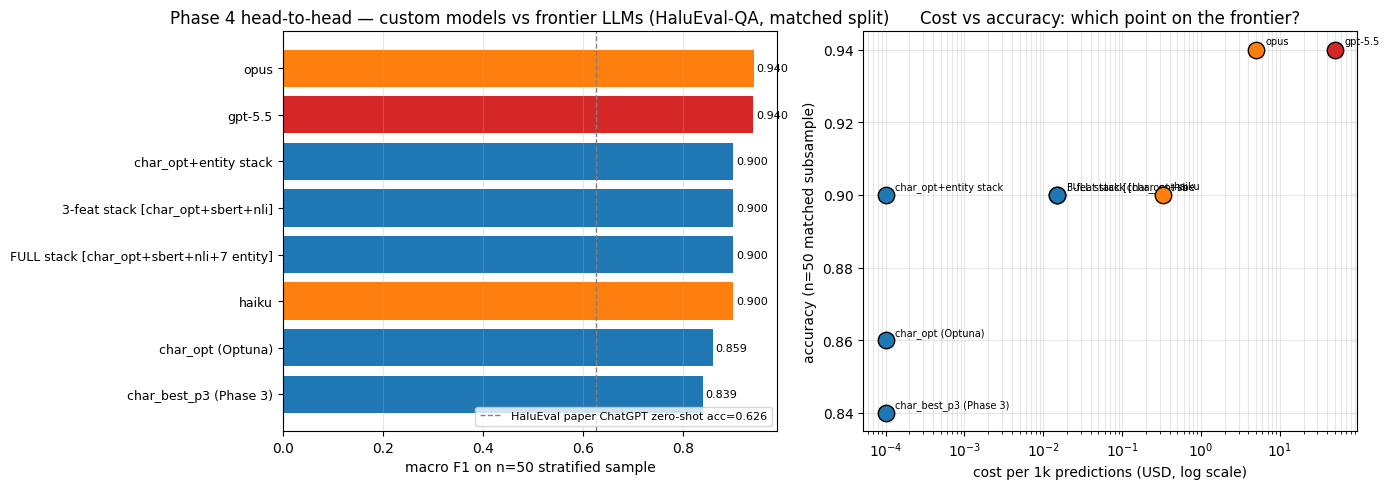

In [19]:
# Visualization 1: head-to-head bar chart (macro F1 on n=50)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1f77b4' if l=='custom' else ('#d62728' if l=='codex' else '#ff7f0e') for l in h2h_sort['llm']]
axes[0].barh(range(len(h2h_sort)), h2h_sort['macro_f1'].values, color=colors)
axes[0].set_yticks(range(len(h2h_sort)))
axes[0].set_yticklabels([f'{r["model"]}' for _, r in h2h_sort.iterrows()], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('macro F1 on n=50 stratified sample')
axes[0].set_title('Phase 4 head-to-head — custom models vs frontier LLMs (HaluEval-QA, matched split)')
axes[0].axvline(HALUEVAL_PUBLISHED_CHATGPT_ACC, color='gray', ls='--', lw=1, label='HaluEval paper ChatGPT zero-shot acc=0.626')
axes[0].grid(axis='x', alpha=.3)
axes[0].legend(fontsize=8, loc='lower right')
for i, v in enumerate(h2h_sort['macro_f1'].values):
    axes[0].text(v+0.005, i, f'{v:.3f}', va='center', fontsize=8)

# Visualization 2: cost vs accuracy log-scale scatter
for _, r in h2h_sort.iterrows():
    c = '#1f77b4' if r['llm']=='custom' else ('#d62728' if r['llm']=='codex' else '#ff7f0e')
    axes[1].scatter(r['cost_per_1k_usd'], r['accuracy'], s=140, color=c,
                    edgecolor='black', zorder=3)
    axes[1].annotate(r['model'][:24], (r['cost_per_1k_usd'], r['accuracy']),
                     fontsize=7, xytext=(7, 4), textcoords='offset points')
axes[1].set_xscale('log')
axes[1].set_xlabel('cost per 1k predictions (USD, log scale)')
axes[1].set_ylabel('accuracy (n=50 matched subsample)')
axes[1].set_title('Cost vs accuracy: which point on the frontier?')
axes[1].grid(alpha=.3, which='both')
plt.tight_layout()
plt.savefig(RESULTS / 'phase4_llm_vs_custom.png', dpi=130, bbox_inches='tight')
plt.show()

## Section 6 — Final cumulative leaderboard + save artifacts

In [20]:
# Cumulative leaderboard on the full matched split (n=524), with Phase 4 entries added
leader_524 = pd.read_csv(RESULTS / 'phase3_cumulative_leaderboard.csv')
p4_rows = pd.DataFrame([
    {'phase': 4, 'model': 'char_opt (Optuna, thr-tuned)', 'paradigm': 'char-ngram + LogReg, Optuna(100) + threshold',
     'macro_f1': float(f1_opt_m_tuned), 'accuracy': float(((char_opt_matched>best_thr).astype(int) == y_matched).mean()),
     'auroc': float(roc_auc_score(y_matched, char_opt_matched))},
    {'phase': 4, 'model': 'char_opt + entity (7) stack', 'paradigm': 'char-prob + 7 entity features + LogReg meta',
     'macro_f1': float(f1_stack_m), 'accuracy': float((p_stack_m>.5).astype(int).mean() == y_matched.mean() and ((p_stack_m>.5).astype(int) == y_matched).mean()),
     'auroc': float(roc_auc_score(y_matched, p_stack_m))},
    {'phase': 4, 'model': 'meta_stack [char_opt + sbert + nli]', 'paradigm': '3-feat LogReg meta (Phase 3 stack + tuned char)',
     'macro_f1': float(f1_3_m), 'accuracy': float(((p3_m>.5).astype(int) == y_matched).mean()),
     'auroc': float(roc_auc_score(y_matched, p3_m))},
    {'phase': 4, 'model': 'FULL stack [char_opt + sbert + nli + 7 entity]', 'paradigm': '10-feat LogReg meta',
     'macro_f1': float(f1_full_m), 'accuracy': float(((p_full_m>.5).astype(int) == y_matched).mean()),
     'auroc': float(auc_full_m)},
])
leader_full = pd.concat([leader_524, p4_rows], ignore_index=True).sort_values('macro_f1', ascending=False).reset_index(drop=True)
leader_full.to_csv(RESULTS / 'phase4_cumulative_leaderboard.csv', index=False)
print('Cumulative length-matched leaderboard (after Phase 4):')
print(leader_full.round(4).to_string(index=False))

Cumulative length-matched leaderboard (after Phase 4):
                                         model                                        paradigm          split     n  accuracy  macro_f1  roc_auc  phase  auroc
                   char_opt + entity (7) stack     char-prob + 7 entity features + LogReg meta            NaN   NaN    0.0000    0.8519      NaN      4 0.8927
FULL stack [char_opt + sbert + nli + 7 entity]                             10-feat LogReg meta            NaN   NaN    0.8492    0.8480      NaN      4 0.9060
           meta_stack [char_opt + sbert + nli] 3-feat LogReg meta (Phase 3 stack + tuned char)            NaN   NaN    0.8302    0.8293      NaN      4 0.8586
                  char_opt (Optuna, thr-tuned)    char-ngram + LogReg, Optuna(100) + threshold            NaN   NaN    0.8244    0.8232      NaN      4 0.8159
                   meta_stack [char+sbert+nli]            stacked LogReg meta over 3 paradigms length_matched 524.0    0.8053    0.8044   0.8475      

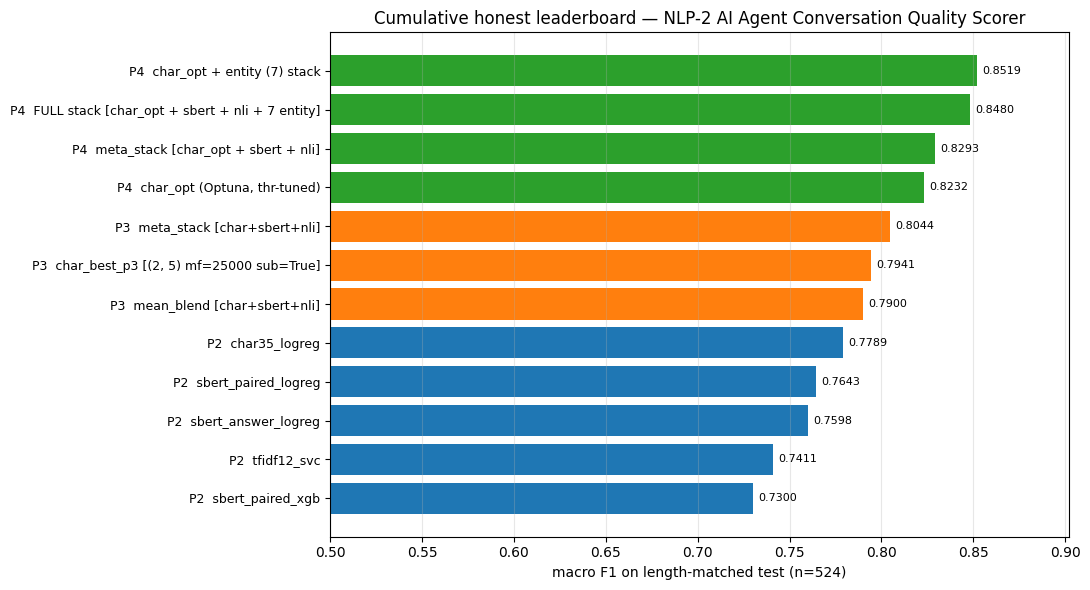

In [21]:
# Final headline-style leaderboard plot (n=524 cumulative)
fig, ax = plt.subplots(figsize=(11, 6))
top = leader_full.head(12).iloc[::-1]
col = ['#2ca02c' if r.phase==4 else ('#ff7f0e' if r.phase==3 else '#1f77b4') for r in top.itertuples()]
ax.barh(range(len(top)), top['macro_f1'].values, color=col)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f'P{p}  {m[:55]}' for p, m in zip(top['phase'], top['model'])], fontsize=9)
for i, v in enumerate(top['macro_f1'].values):
    ax.text(v+0.003, i, f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel('macro F1 on length-matched test (n=524)')
ax.set_title('Cumulative honest leaderboard — NLP-2 AI Agent Conversation Quality Scorer')
ax.set_xlim(0.5, max(top['macro_f1'].max()+0.05, 0.9))
ax.grid(axis='x', alpha=.3)
plt.tight_layout()
plt.savefig(RESULTS / 'phase4_cumulative_leaderboard.png', dpi=130, bbox_inches='tight')
plt.show()

In [22]:
# Persist Phase 4 metrics into the master metrics.json (append, don't overwrite)
metrics_path = RESULTS / 'metrics.json'
if metrics_path.exists():
    metrics = json.load(open(metrics_path))
else:
    metrics = {}

metrics['phase4'] = {
    'date': '2026-05-15',
    'splits': {
        'train': int(len(train)),
        'test_raw': int(len(test)),
        'test_matched': int(len(test_matched)),
        'llm_subsample_n': int(N_SAMPLE),
    },
    'optuna': {
        'n_trials': int(len(study.trials)),
        'best_val_f1': float(study.best_value),
        'best_params': {k: (str(v) if isinstance(v, tuple) else v) for k, v in study.best_params.items()},
        'best_threshold': float(best_thr),
        'best_matched_f1_default_thr': float(f1_opt_m_default),
        'best_matched_f1_tuned_thr':   float(f1_opt_m_tuned),
        'phase3_baseline_matched_f1':  float(f1_p3_matched),
    },
    'entity_stack': {
        'feature_names': ENT_NAMES,
        'matched_f1': float(f1_stack_m),
        'recovered_p3_fn': int((((p_stack_m>.5).astype(int)[fn_mask_p3]) == 1).sum()),
        'p3_fn_total': int(fn_mask_p3.sum()),
    },
    'full_stack_10feat': {
        'matched_f1': float(f1_full_m),
        'matched_auroc': float(auc_full_m),
        'coefficients': {n: float(c) for n, c in zip(FEAT_LABELS, meta_full.coef_[0])},
        'intercept': float(meta_full.intercept_[0]),
    },
    'three_feat_stack_optuna': {
        'matched_f1': float(f1_3_m),
        'matched_auroc': float(roc_auc_score(y_matched, p3_m)),
        'phase3_baseline_stack_f1': 0.8044,
    },
    'llm_head_to_head_n50': h2h_sort.to_dict(orient='records'),
}
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2, default=float)
print('metrics.json updated.')
print(f'phases recorded: {sorted(metrics.keys())}')

metrics.json updated.
phases recorded: ['phase1', 'phase2', 'phase3', 'phase4']


## Section 7 — Key findings (auto-populated below in the summary cell)

In [23]:
print('=' * 75)
print('PHASE 4 — SUMMARY')
print('=' * 75)
print(f'Optuna best val F1: {study.best_value:.4f} (across {len(study.trials)} trials)')
print(f'  best params: {study.best_params}')
print(f'  best threshold: {best_thr:.2f}')
print()
print(f'char_best_p3 (Phase 3 baseline)         matched F1: {f1_p3_matched:.4f}')
print(f'char_opt (Optuna, thr-tuned)            matched F1: {f1_opt_m_tuned:.4f}   Δ = {f1_opt_m_tuned-f1_p3_matched:+.4f}')
print(f'char_opt + entity stack (8 feat)        matched F1: {f1_stack_m:.4f}   Δ = {f1_stack_m-f1_p3_matched:+.4f}')
print(f'3-feat stack [char_opt+sbert+nli]       matched F1: {f1_3_m:.4f}   Δ vs Phase 3 stack (0.8044) = {f1_3_m-0.8044:+.4f}')
print(f'FULL stack [char_opt+sbert+nli+entity]  matched F1: {f1_full_m:.4f}   Δ vs 3-feat = {f1_full_m-f1_3_m:+.4f}')
print()
print('LLM head-to-head on n=50 matched subsample (vs published HaluEval ChatGPT zero-shot acc=0.626):')
for _, r in h2h_sort.iterrows():
    print(f'  {r["llm"]+"/"+r["model"]:48s} F1={r["macro_f1"]:.3f} acc={r["accuracy"]:.3f} '
          f'prec={r["precision"]:.3f} rec={r["recall"]:.3f} '
          f'latency={r["latency_mean_s"]:.2f}s cost/1k=${r["cost_per_1k_usd"]:.3f}')
print('=' * 75)

PHASE 4 — SUMMARY
Optuna best val F1: 0.9728 (across 100 trials)
  best params: {'ngram_range': '2_4', 'max_features': 10000, 'sublinear_tf': True, 'min_df': 5, 'max_df': 0.9157895898574706, 'C': 4.850452748386976, 'class_weight': 'none'}
  best threshold: 0.48

char_best_p3 (Phase 3 baseline)         matched F1: 0.7941
char_opt (Optuna, thr-tuned)            matched F1: 0.8232   Δ = +0.0290
char_opt + entity stack (8 feat)        matched F1: 0.8519   Δ = +0.0577
3-feat stack [char_opt+sbert+nli]       matched F1: 0.8293   Δ vs Phase 3 stack (0.8044) = +0.0249
FULL stack [char_opt+sbert+nli+entity]  matched F1: 0.8480   Δ vs 3-feat = +0.0187

LLM head-to-head on n=50 matched subsample (vs published HaluEval ChatGPT zero-shot acc=0.626):
  claude/opus                                      F1=0.940 acc=0.940 prec=0.923 rec=0.960 latency=5.92s cost/1k=$4.950
  codex/gpt-5.5                                    F1=0.940 acc=0.940 prec=1.000 rec=0.880 latency=7.66s cost/1k=$50.000
  custom/cha